In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv("housing.csv")
data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [6]:
data.dropna(inplace=True)
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.7+ MB


In [40]:
from sklearn.model_selection import train_test_split

X = data.drop(["median_house_value"], axis=1)
y = data["median_house_value"]

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

In [41]:
train_data = X_train.join(y_train)

In [43]:
train_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
6111,-117.90,34.13,25.0,3076.0,856.0,2868.0,752.0,2.6619,<1H OCEAN,117600.0
20517,-121.54,38.58,30.0,4648.0,1252.0,2524.0,1089.0,1.3177,INLAND,74300.0
6311,-118.00,34.03,25.0,6909.0,1154.0,3912.0,1121.0,5.2570,<1H OCEAN,226100.0
9494,-123.85,39.39,23.0,4671.0,912.0,2095.0,857.0,3.1840,<1H OCEAN,140500.0
1252,-122.51,39.30,19.0,1629.0,386.0,551.0,214.0,1.7463,INLAND,68800.0
...,...,...,...,...,...,...,...,...,...,...
11055,-117.85,33.77,16.0,2186.0,511.0,908.0,466.0,4.5750,<1H OCEAN,225000.0
19937,-119.38,36.30,14.0,1932.0,330.0,997.0,291.0,3.6875,INLAND,93200.0
16179,-121.28,37.96,28.0,1942.0,724.0,1618.0,638.0,0.9365,INLAND,52500.0
4154,-118.20,34.11,46.0,3659.0,1068.0,4153.0,993.0,2.5211,<1H OCEAN,162900.0


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

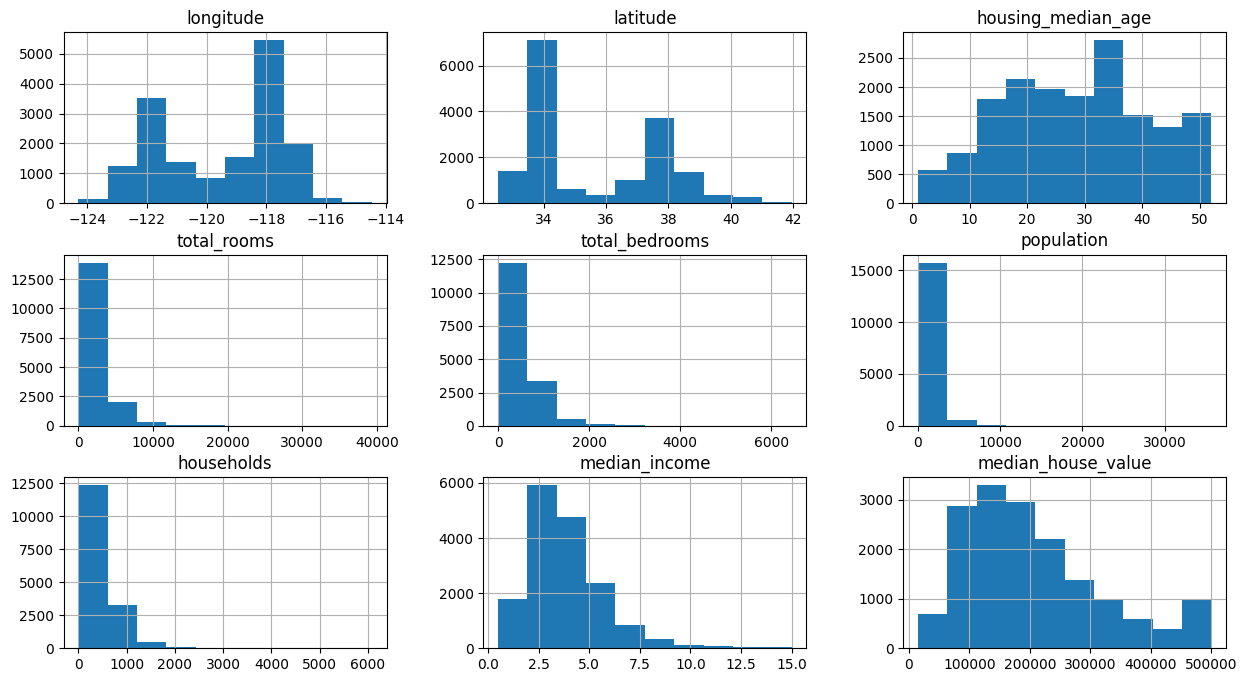

In [45]:
train_data.hist(figsize=(15, 8))

<Axes: >

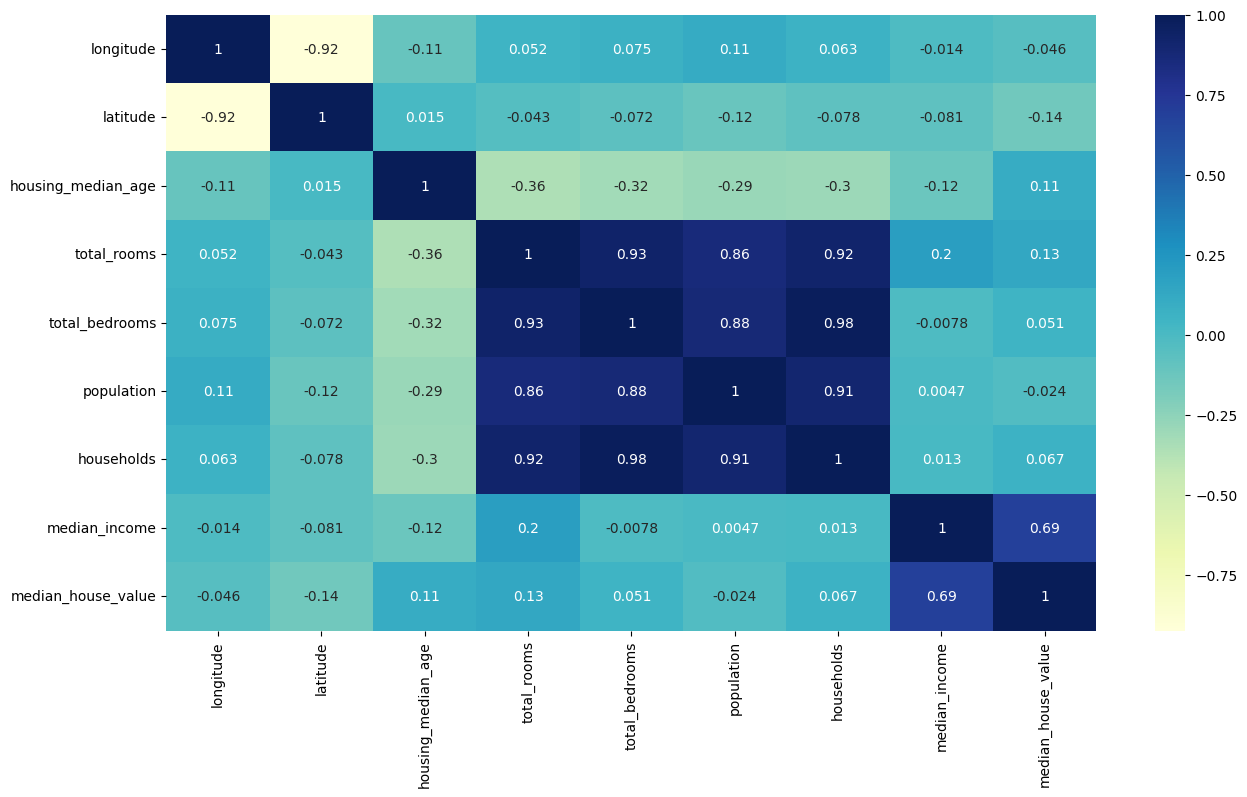

In [49]:
plt.figure(figsize=(15, 8))
sns.heatmap(train_data.corr(numeric_only=True), annot=True, cmap="YlGnBu")

In [50]:
train_data['total_rooms'] = np.log1p(train_data['total_rooms'] + 1)
train_data['total_bedrooms'] = np.log1p(train_data['total_bedrooms'] + 1)
train_data['population'] = np.log1p(train_data['population'] + 1)
train_data['households'] = np.log1p(train_data['households'] + 1)

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

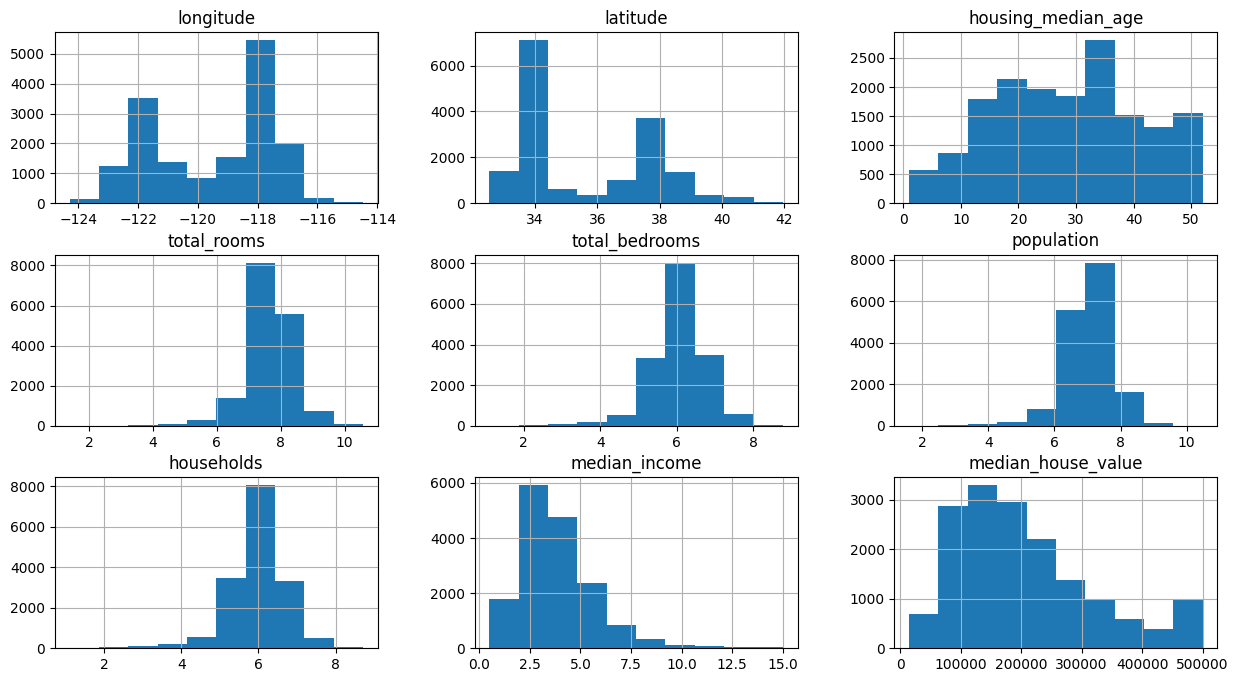

In [51]:
train_data.hist(figsize=(15, 8))

In [59]:
train_data = train_data.join(pd.get_dummies(train_data["ocean_proximity"], dtype=int)).drop(['ocean_proximity'], axis=1)

In [60]:
train_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
6111,-117.90,34.13,25.0,8.032035,6.754604,7.962067,6.625392,2.6619,117600.0,1,0,0,0,0
20517,-121.54,38.58,30.0,8.444622,7.134094,7.834392,6.994850,1.3177,74300.0,0,1,0,0,0
6311,-118.00,34.03,25.0,8.840870,7.052721,8.272315,7.023759,5.2570,226100.0,1,0,0,0,0
9494,-123.85,39.39,23.0,8.449557,6.817831,7.648263,6.755769,3.1840,140500.0,1,0,0,0,0
1252,-122.51,39.30,19.0,7.396949,5.961005,6.315358,5.375278,1.7463,68800.0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11055,-117.85,33.77,16.0,7.690743,6.240276,6.813445,6.148468,4.5750,225000.0,1,0,0,0,0
19937,-119.38,36.30,14.0,7.567346,5.805135,6.906755,5.680173,3.6875,93200.0,0,1,0,0,0
16179,-121.28,37.96,28.0,7.572503,6.587550,7.390181,6.461468,0.9365,52500.0,0,1,0,0,0
4154,-118.20,34.11,46.0,8.205492,6.975414,8.332068,6.902743,2.5211,162900.0,1,0,0,0,0


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>,
        <Axes: title={'center': 'total_rooms'}>],
       [<Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>,
        <Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>],
       [<Axes: title={'center': 'median_house_value'}>,
        <Axes: title={'center': '<1H OCEAN'}>,
        <Axes: title={'center': 'INLAND'}>,
        <Axes: title={'center': 'ISLAND'}>],
       [<Axes: title={'center': 'NEAR BAY'}>,
        <Axes: title={'center': 'NEAR OCEAN'}>, <Axes: >, <Axes: >]],
      dtype=object)

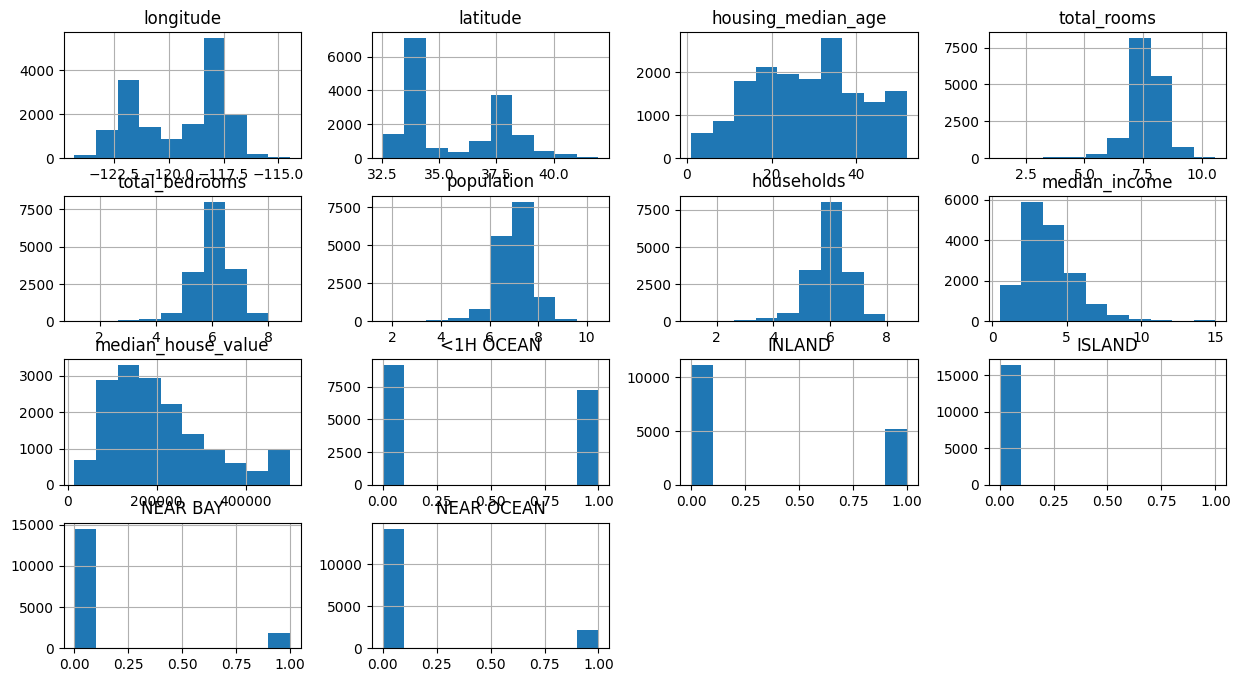

In [61]:
train_data.hist(figsize=(15, 8))

<Axes: xlabel='latitude', ylabel='longitude'>

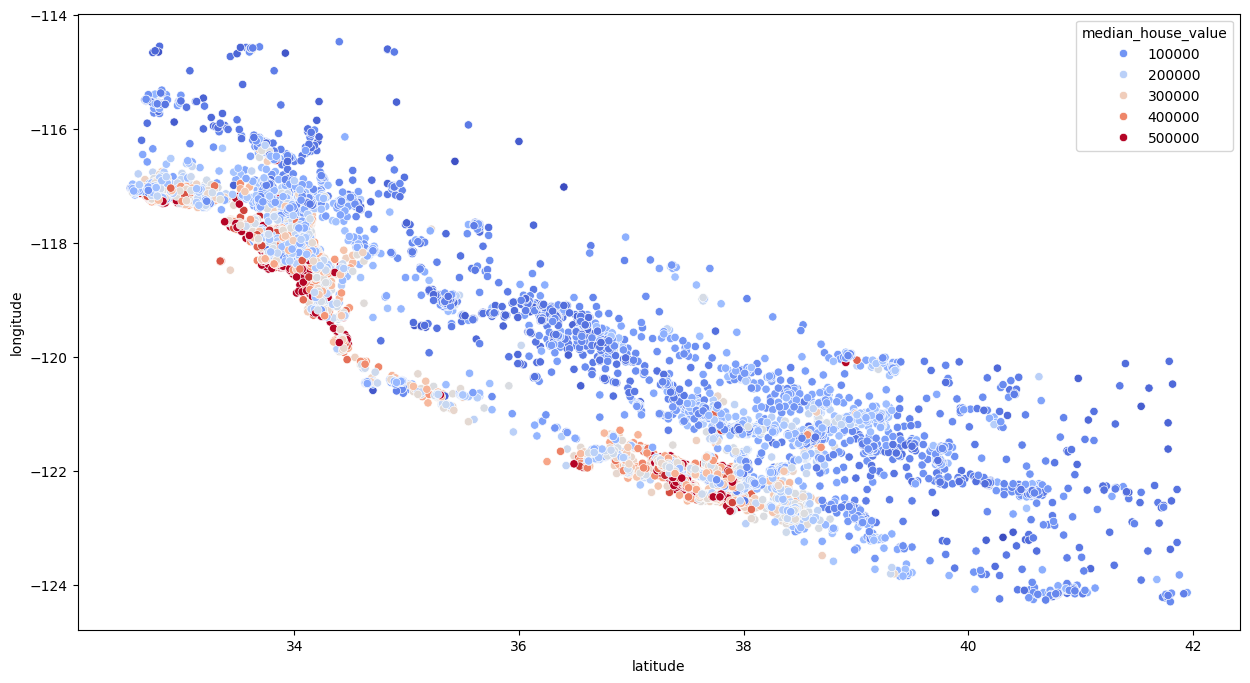

In [62]:
plt.figure(figsize=(15, 8))
sns.scatterplot(x="latitude", y="longitude", data=train_data, hue="median_house_value", palette='coolwarm')

In [63]:
train_data['bedroom_ratio'] = train_data['total_bedrooms'] / train_data['total_rooms']
train_data['household_rooms'] = train_data['total_rooms'] / train_data['households']

<Axes: >

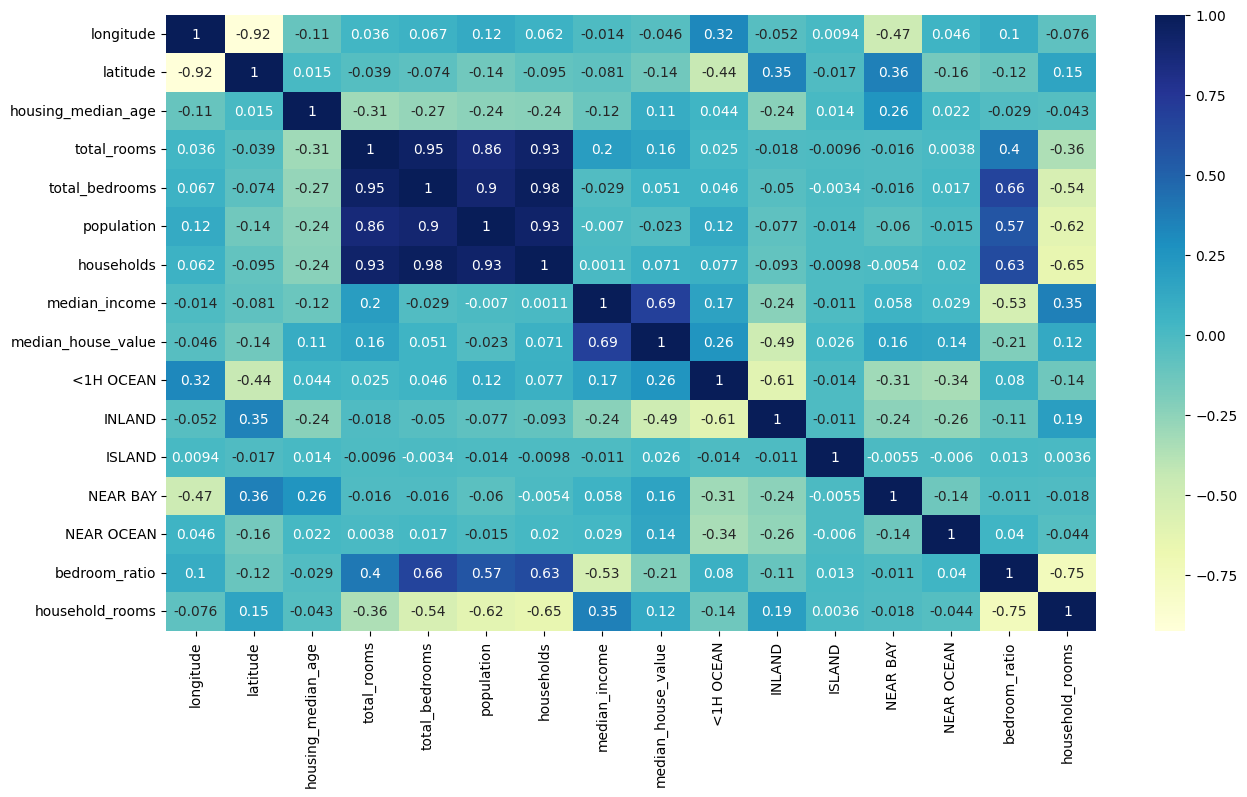

In [64]:
plt.figure(figsize=(15, 8))
sns.heatmap(train_data.corr(numeric_only=True), annot=True, cmap="YlGnBu")

In [74]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()


X_train, y_train = train_data.drop(["median_house_value"], axis=1), train_data["median_house_value"]
X_train_s = scaler.fit_transform(X_train)

reg = LinearRegression()
reg.fit(X_train_s, y_train)

LinearRegression()

In [71]:
test_data = X_test.join(y_test)

test_data['total_rooms'] = np.log1p(test_data['total_rooms'] + 1)
test_data['total_bedrooms'] = np.log1p(test_data['total_bedrooms'] + 1)
test_data['population'] = np.log1p(test_data['population'] + 1)
test_data['households'] = np.log1p(test_data['households'] + 1)

test_data = test_data.join(pd.get_dummies(test_data["ocean_proximity"], dtype=int)).drop(['ocean_proximity'], axis=1)

test_data['bedroom_ratio'] = test_data['total_bedrooms'] / test_data['total_rooms']
test_data['household_rooms'] = test_data['total_rooms'] / test_data['households']

X_test, y_test = test_data.drop(["median_house_value"], axis=1), test_data["median_house_value"]

In [72]:
X_test, y_test = test_data.drop(["median_house_value"], axis=1), test_data["median_house_value"]

In [75]:
X_test_s = scaler.transform(X_test)

In [76]:
reg.score(X_test_s, y_test)

0.6773618202960319

In [80]:
from sklearn.ensemble import RandomForestRegressor

forest = RandomForestRegressor()

forest.fit(X_train_s, y_train)

RandomForestRegressor()

In [81]:
forest.score(X_test_s, y_test)

0.8195821929828713

In [87]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'min_samples_split': [2, 4],
    'max_depth': [None, 4, 8],

}

grid_search = GridSearchCV(forest, param_grid, cv=5, scoring='neg_mean_squared_error', return_train_score=True)

grid_search.fit(X_train_s, y_train)


GridSearchCV(cv=5, estimator=RandomForestRegressor(),
             param_grid={'max_depth': [None, 4, 8], 'min_samples_split': [2, 4],
                         'n_estimators': [100, 200, 300]},
             return_train_score=True, scoring='neg_mean_squared_error')

In [89]:
grid_search.best_estimator_

RandomForestRegressor(n_estimators=300)

In [90]:
grid_search.best_estimator_.score(X_test_s, y_test)

0.8205299682754386